# 12. Correlation Matrix for the GNN 16-Product M5 Subset

This notebook recovers the same 16-product subset used in the original graph forecasting experiment and computes the full 16x16 Pearson correlation matrix.

It is organized to support the next graph-construction step with correlation thresholds such as `0.5`, `0.8`, `0.9`, and `0.99`.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'gnn_model_comparison':
    REPO_ROOT = REPO_ROOT.parent.parent
elif REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

VENV_SITE_PACKAGES = REPO_ROOT / '.venv' / 'Lib' / 'site-packages'
if VENV_SITE_PACKAGES.exists() and str(VENV_SITE_PACKAGES) not in sys.path:
    sys.path.insert(0, str(VENV_SITE_PACKAGES))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from IPython.display import Image, display

from src.experiments.run_correlation_matrix_16_products import main

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## Source of the 16-product subset

The subset is recovered with the same logic used in the original graph notebook:

- source notebook: `notebooks/29_graph_neural_network.ipynb`
- source loader: `src/data_loaders/load_m5_panel.py`
- exact selection parameters: `num_products=16`, `state_id='CA'`, `seed=42`, `min_nonzero_days=28`, `max_days=365`

This preserves the same product set, daily horizon, and truncation window used by the GNN experiment.

In [2]:
outputs = main()
metadata = outputs['metadata'].copy()
sales_df = outputs['sales_df'].copy()
corr_df = outputs['corr_df'].copy()
top_pairs_df = outputs['top_pairs_df'].copy()
connectivity_df = outputs['connectivity_df'].copy()
threshold_df = outputs['threshold_df'].copy()

print('Reports directory:', outputs['reports_dir'])
print('Date range:', sales_df.index.min().date(), '->', sales_df.index.max().date())
print('Sales panel shape:', sales_df.shape)
print('Correlation matrix shape:', corr_df.shape)

Reports directory: C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\correlation_matrix_16_products
Date range: 2015-04-26 -> 2016-04-24
Sales panel shape: (365, 16)
Correlation matrix shape: (16, 16)


In [3]:
metadata[['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'nonzero_days', 'mean_sales', 'zero_rate']]

,id,item_id,dept_id,cat_id,store_id,state_id,nonzero_days,mean_sales,zero_rate
0,FOODS_2_397_CA_2_validation,FOODS_2_397,FOODS_2,FOODS,CA_2,CA,98,0.4082,0.7315
1,FOODS_2_044_CA_3_validation,FOODS_2_044,FOODS_2,FOODS,CA_3,CA,856,0.7315,0.6082
2,FOODS_3_228_CA_1_validation,FOODS_3_228,FOODS_3,FOODS,CA_1,CA,1901,7.0082,0.0110
3,FOODS_3_070_CA_2_validation,FOODS_3_070,FOODS_3,FOODS,CA_2,CA,704,3.5096,0.4301
4,FOODS_3_170_CA_3_validation,FOODS_3_170,FOODS_3,FOODS,CA_3,CA,593,1.4027,0.4000
5,FOODS_3_420_CA_3_validation,FOODS_3_420,FOODS_3,FOODS,CA_3,CA,785,0.5918,0.5918
6,FOODS_3_641_CA_3_validation,FOODS_3_641,FOODS_3,FOODS,CA_3,CA,551,1.0384,0.4658
7,FOODS_3_524_CA_4_validation,FOODS_3_524,FOODS_3,FOODS,CA_4,CA,1065,2.0356,0.4932
8,HOBBIES_1_323_CA_3_validation,HOBBIES_1_323,HOBBIES_1,HOBBIES,CA_3,CA,1634,1.4493,0.2849
9,HOBBIES_1_133_CA_4_validation,HOBBIES_1_133,HOBBIES_1,HOBBIES,CA_4,CA,174,0.0548,0.9479


In [4]:
sales_df.head()

,FOODS_2_397_CA_2_validation,FOODS_2_044_CA_3_validation,FOODS_3_228_CA_1_validation,FOODS_3_070_CA_2_validation,FOODS_3_170_CA_3_validation,FOODS_3_420_CA_3_validation,FOODS_3_641_CA_3_validation,FOODS_3_524_CA_4_validation,HOBBIES_1_323_CA_3_validation,HOBBIES_1_133_CA_4_validation,HOBBIES_1_284_CA_4_validation,HOBBIES_2_019_CA_4_validation,HOUSEHOLD_1_492_CA_1_validation,HOUSEHOLD_1_531_CA_1_validation,HOUSEHOLD_2_051_CA_1_validation,HOUSEHOLD_2_221_CA_4_validation
date,,,,,,,,,,,,,,,,
2015-04-26,0.0000,0.0000,13.0000,1.0000,1.0000,2.0000,4.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
2015-04-27,0.0000,0.0000,6.0000,0.0000,0.0000,1.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000
2015-04-28,0.0000,0.0000,11.0000,0.0000,2.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
2015-04-29,0.0000,0.0000,9.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
2015-04-30,0.0000,0.0000,5.0000,0.0000,1.0000,1.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,1.0000,0.0000


In [5]:
corr_df

,FOODS_2_397_CA_2_validation,FOODS_2_044_CA_3_validation,FOODS_3_228_CA_1_validation,FOODS_3_070_CA_2_validation,FOODS_3_170_CA_3_validation,FOODS_3_420_CA_3_validation,FOODS_3_641_CA_3_validation,FOODS_3_524_CA_4_validation,HOBBIES_1_323_CA_3_validation,HOBBIES_1_133_CA_4_validation,HOBBIES_1_284_CA_4_validation,HOBBIES_2_019_CA_4_validation,HOUSEHOLD_1_492_CA_1_validation,HOUSEHOLD_1_531_CA_1_validation,HOUSEHOLD_2_051_CA_1_validation,HOUSEHOLD_2_221_CA_4_validation
FOODS_2_397_CA_2_validation,1.0000,0.0820,0.2045,-0.0800,0.0886,0.0683,-0.0579,0.1540,-0.0456,0.0568,0.0195,-0.0285,0.0235,0.0109,0.0416,0.0293
FOODS_2_044_CA_3_validation,0.0820,1.0000,-0.0089,-0.0554,0.0860,0.0430,0.0907,0.0081,0.0161,0.0134,-0.0122,-0.0802,-0.0049,-0.0029,0.0363,0.0629
FOODS_3_228_CA_1_validation,0.2045,-0.0089,1.0000,-0.0833,0.0351,-0.0070,-0.0502,0.0618,0.0200,0.0650,0.0542,0.0766,-0.0558,0.1636,0.1107,0.0038
FOODS_3_070_CA_2_validation,-0.0800,-0.0554,-0.0833,1.0000,-0.0742,0.0962,-0.0245,0.0501,0.0191,-0.0451,0.0659,-0.0349,0.0195,0.0322,-0.0493,-0.0391
FOODS_3_170_CA_3_validation,0.0886,0.0860,0.0351,-0.0742,1.0000,0.0089,-0.0153,-0.0919,-0.1300,-0.1305,0.0584,-0.0451,0.1324,0.0143,-0.0430,-0.0026
FOODS_3_420_CA_3_validation,0.0683,0.0430,-0.0070,0.0962,0.0089,1.0000,-0.0526,0.1853,-0.1311,0.0677,0.0047,-0.0307,-0.0505,0.0927,-0.0051,0.0854
FOODS_3_641_CA_3_validation,-0.0579,0.0907,-0.0502,-0.0245,-0.0153,-0.0526,1.0000,0.0107,0.0280,-0.0063,-0.0625,0.0503,0.1225,-0.0167,-0.0054,-0.0666
FOODS_3_524_CA_4_validation,0.1540,0.0081,0.0618,0.0501,-0.0919,0.1853,0.0107,1.0000,-0.0074,0.0348,-0.0031,-0.0140,-0.0284,-0.0466,0.1286,0.0143
HOBBIES_1_323_CA_3_validation,-0.0456,0.0161,0.0200,0.0191,-0.1300,-0.1311,0.0280,-0.0074,1.0000,0.0522,-0.0406,0.0889,-0.0841,-0.0768,0.0596,0.0807
HOBBIES_1_133_CA_4_validation,0.0568,0.0134,0.0650,-0.0451,-0.1305,0.0677,-0.0063,0.0348,0.0522,1.0000,-0.0214,0.0581,-0.0341,0.0486,0.0895,0.0249


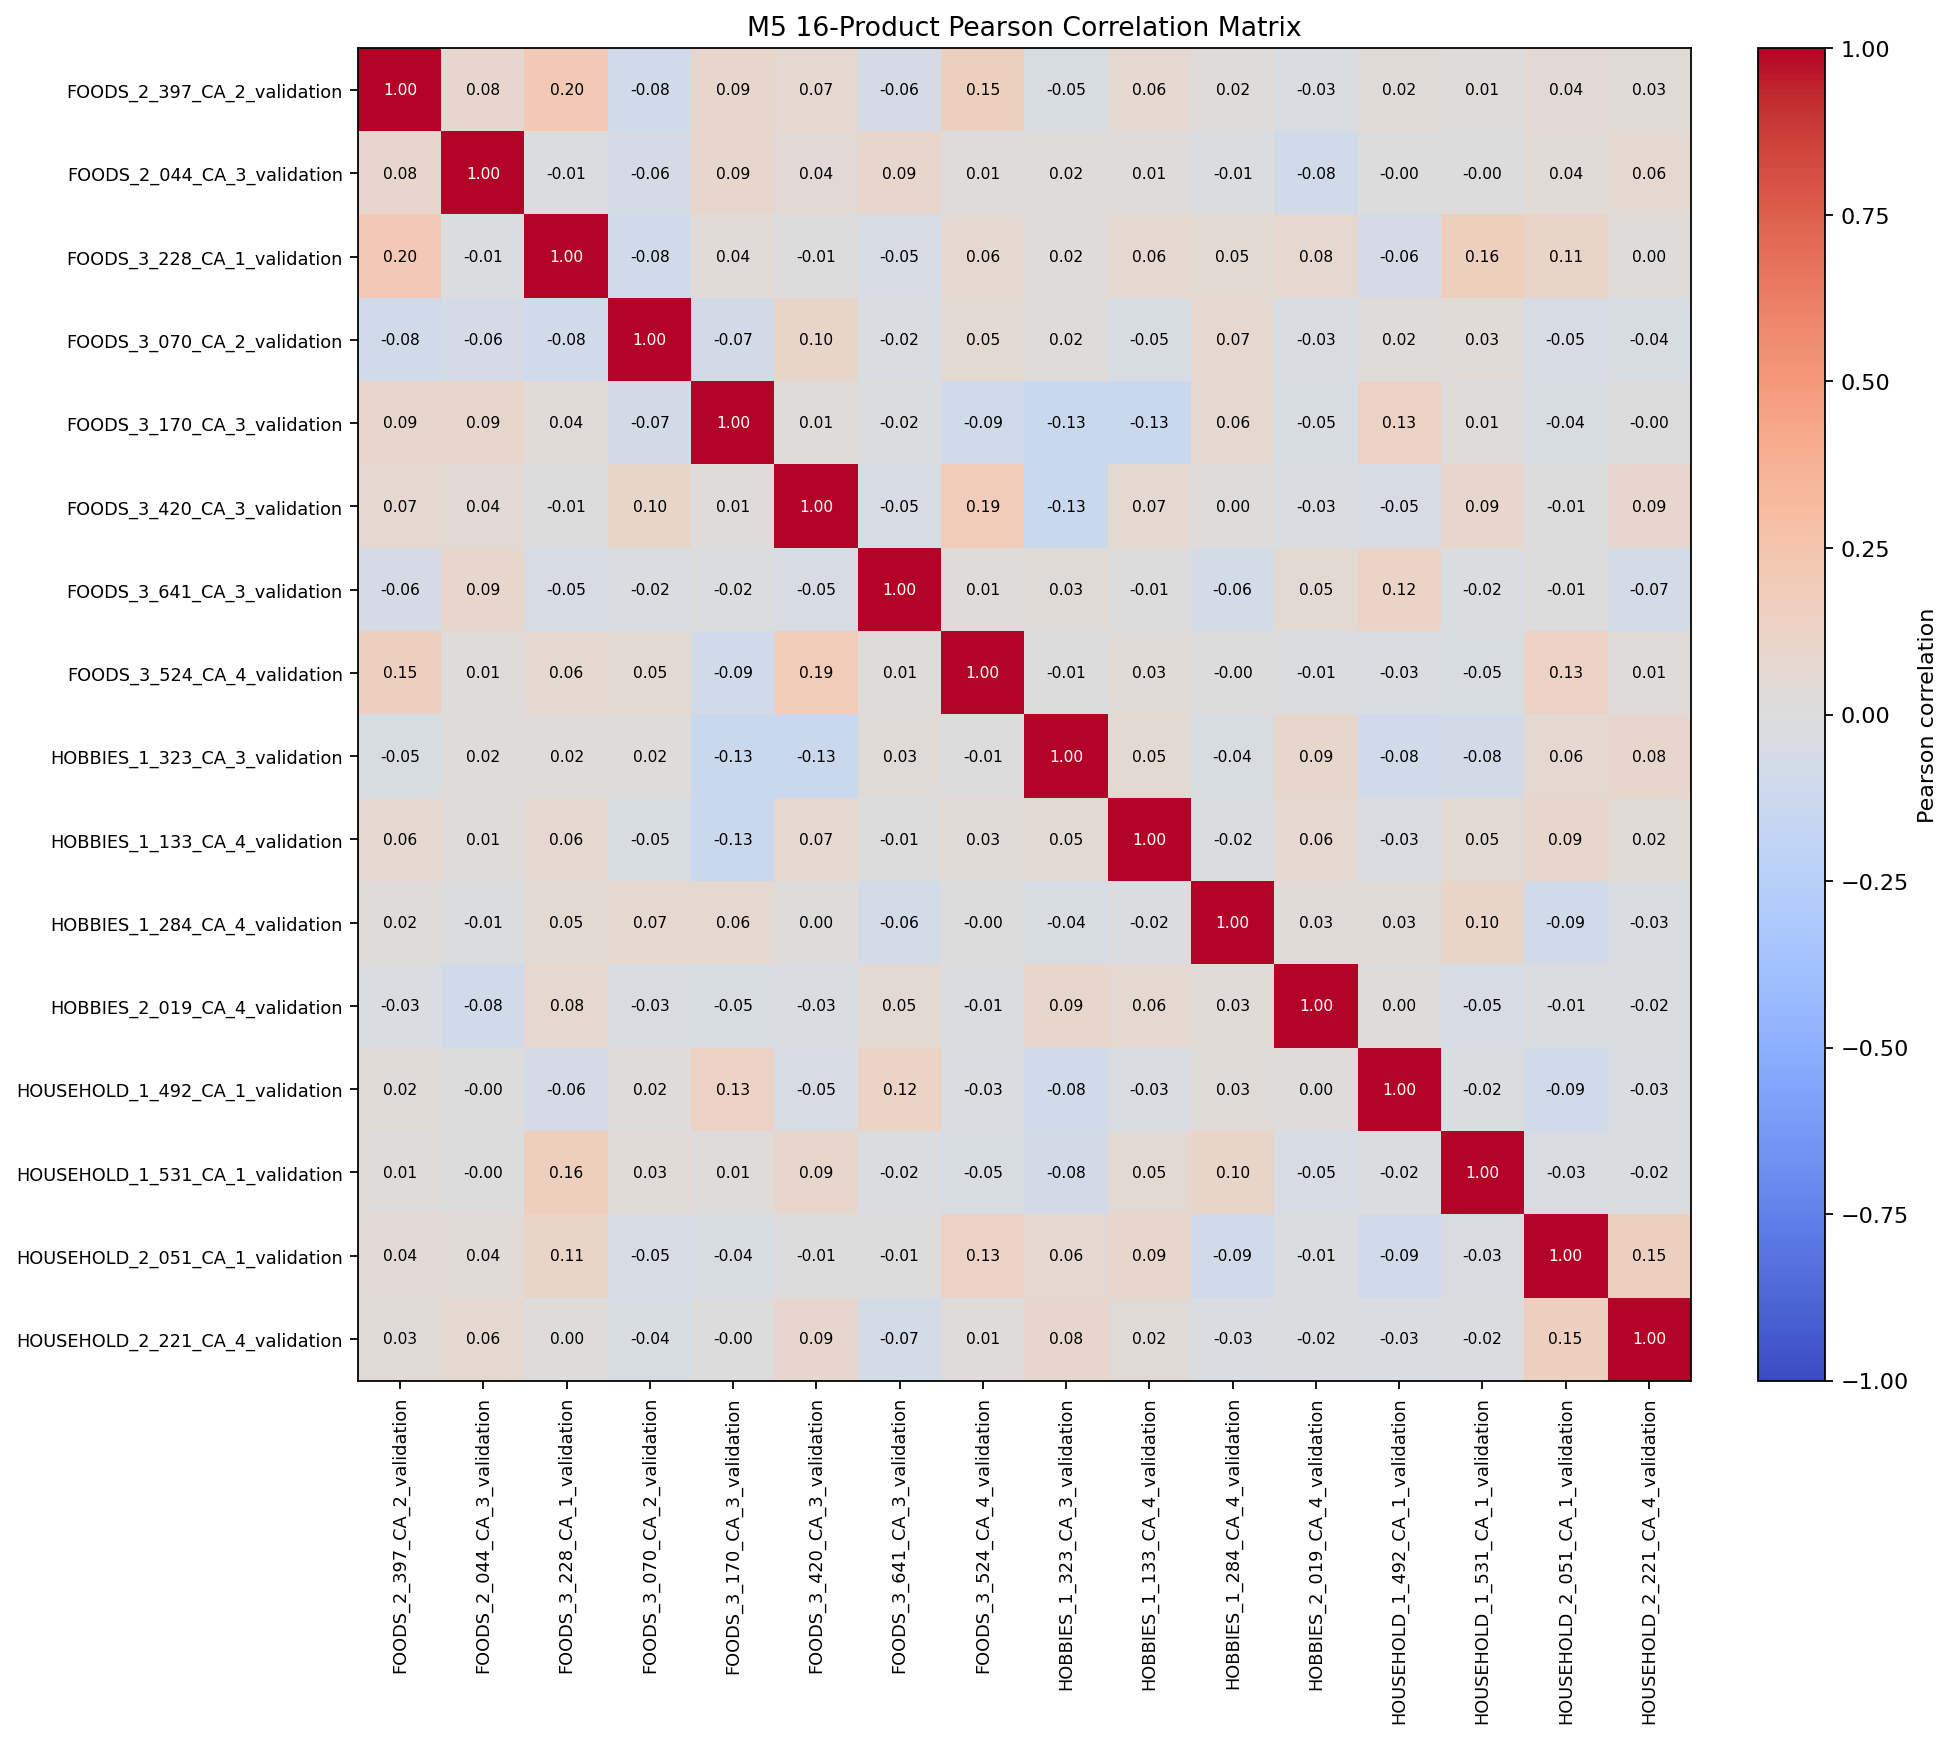

In [6]:
display(Image(filename=str(outputs['figure_path'])))

In [7]:
top_pairs_df.head(15)

,product_a,product_b,correlation,abs_correlation
0,FOODS_2_397_CA_2_validation,FOODS_3_228_CA_1_validation,0.2045,0.2045
1,FOODS_3_420_CA_3_validation,FOODS_3_524_CA_4_validation,0.1853,0.1853
2,FOODS_3_228_CA_1_validation,HOUSEHOLD_1_531_CA_1_validation,0.1636,0.1636
3,FOODS_2_397_CA_2_validation,FOODS_3_524_CA_4_validation,0.1540,0.1540
4,HOUSEHOLD_2_051_CA_1_validation,HOUSEHOLD_2_221_CA_4_validation,0.1497,0.1497
5,FOODS_3_170_CA_3_validation,HOUSEHOLD_1_492_CA_1_validation,0.1324,0.1324
6,FOODS_3_420_CA_3_validation,HOBBIES_1_323_CA_3_validation,-0.1311,0.1311
7,FOODS_3_170_CA_3_validation,HOBBIES_1_133_CA_4_validation,-0.1305,0.1305
8,FOODS_3_170_CA_3_validation,HOBBIES_1_323_CA_3_validation,-0.1300,0.1300
9,FOODS_3_524_CA_4_validation,HOUSEHOLD_2_051_CA_1_validation,0.1286,0.1286


In [8]:
connectivity_df

,category,pair_type,mean_correlation
0,FOODS,cross_category,0.0086
1,FOODS,within_category,0.0240
2,HOBBIES,cross_category,-0.0024
3,HOBBIES,within_category,0.0285
4,HOUSEHOLD,cross_category,0.0156
5,HOUSEHOLD,within_category,-0.0058


In [9]:
threshold_df

,threshold,edge_count,pair_coverage
0,0.5000,0,0.0000
1,0.8000,0,0.0000
2,0.9000,0,0.0000
3,0.9900,0,0.0000


## Interpretation

The cells above expose the strongest product pairs, category-level connectivity, and the full correlation matrix. These exports are ready to be reused for threshold-based graph construction.

Recommended next step:

- start with `correlation >= 0.5`
- then compare graph sparsity and connectivity against `0.8`, `0.9`, and `0.99`

In [10]:
for line in outputs['interpretation_lines']:
    print('-', line)

print('\nSaved files:')
print('-', outputs['corr_csv'])
print('-', outputs['sales_csv'])
print('-', outputs['top_pairs_csv'])
print('-', outputs['connectivity_csv'])
print('-', outputs['threshold_csv'])
print('-', outputs['figure_path'])
print('-', outputs['summary_path'])

- The same 16-product subset from notebook29 was recovered through load_m5_panel_subset with the original CA / seed=42 / max_days=365 configuration.
- The strongest product-to-product relationships are concentrated in a small set of positive pairs, which supports threshold-based graph construction from the correlation matrix.
- Top correlated pairs: FOODS_2_397_CA_2_validation vs FOODS_3_228_CA_1_validation = 0.205; FOODS_3_420_CA_3_validation vs FOODS_3_524_CA_4_validation = 0.185; FOODS_3_228_CA_1_validation vs HOUSEHOLD_1_531_CA_1_validation = 0.164; FOODS_2_397_CA_2_validation vs FOODS_3_524_CA_4_validation = 0.154; HOUSEHOLD_2_051_CA_1_validation vs HOUSEHOLD_2_221_CA_4_validation = 0.150
- Within-category average connectivity ranks as HOBBIES: 0.029, FOODS: 0.024, HOUSEHOLD: -0.006.
- Hub-like products by absolute correlation strength are FOODS_3_228_CA_1_validation (1.000), FOODS_2_397_CA_2_validation (0.991), FOODS_3_170_CA_3_validation (0.956), HOUSEHOLD_2_051_CA_1_validation 

## Hybrid Product Relationship Matrix

The raw Pearson matrix above is kept as the baseline. This new section extends the same notebook with a stronger hybrid relationship matrix aligned with Notebook 29.

Hybrid formula used in this notebook:

`hybrid_similarity = 0.40 * sales_similarity + 0.35 * metadata_similarity + 0.25 * profile_similarity`

Why these weights:

- `sales_similarity` keeps direct demand co-movement in the graph
- `metadata_similarity` stays close to the structural scoring already used in Notebook 29
- `profile_similarity` rescues relationships between products with similar demand regimes even when raw daily correlation is weak

In [11]:
profile_df = outputs['profile_df'].copy()
daily_corr_df = outputs['daily_corr_df'].copy()
weekly_corr_df = outputs['weekly_corr_df'].copy()
log_corr_df = outputs['log_corr_df'].copy()
sales_similarity_df = outputs['sales_similarity_df'].copy()
metadata_similarity_df = outputs['metadata_similarity_df'].copy()
profile_similarity_df = outputs['profile_similarity_df'].copy()
hybrid_df = outputs['hybrid_df'].copy()
hybrid_top_pairs_df = outputs['hybrid_top_pairs_df'].copy()
hybrid_connectivity_df = outputs['hybrid_connectivity_df'].copy()
hybrid_threshold_df = outputs['hybrid_threshold_df'].copy()
hybrid_weights = outputs['hybrid_weights']

print('Hybrid weights:', hybrid_weights)

Hybrid weights: (0.4, 0.35, 0.25)


In [12]:
profile_df[['id', 'cat_id', 'dept_id', 'mean_sales', 'std_sales', 'zero_rate', 'nonzero_days', 'max_sales', 'ADI', 'CV2']]

,id,cat_id,dept_id,mean_sales,std_sales,zero_rate,nonzero_days,max_sales,ADI,CV2
0,FOODS_2_397_CA_2_validation,FOODS,FOODS_2,0.4082,0.7731,0.7315,98.0000,4.0000,3.7245,0.2316
1,FOODS_2_044_CA_3_validation,FOODS,FOODS_2,0.7315,1.1677,0.6082,143.0000,6.0000,2.5524,0.3901
2,FOODS_3_228_CA_1_validation,FOODS,FOODS_3,7.0082,3.4960,0.0110,361.0000,20.0000,1.0111,0.2352
3,FOODS_3_070_CA_2_validation,FOODS,FOODS_3,3.5096,7.6619,0.4301,208.0000,76.0000,1.7548,2.2859
4,FOODS_3_170_CA_3_validation,FOODS,FOODS_3,1.4027,1.7594,0.4000,219.0000,12.0000,1.6667,0.5439
5,FOODS_3_420_CA_3_validation,FOODS,FOODS_3,0.5918,0.8730,0.5918,149.0000,5.0000,2.4497,0.2966
6,FOODS_3_641_CA_3_validation,FOODS,FOODS_3,1.0384,1.3902,0.4658,195.0000,9.0000,1.8718,0.4919
7,FOODS_3_524_CA_4_validation,FOODS,FOODS_3,2.0356,3.0532,0.4932,185.0000,17.0000,1.9730,0.6471
8,HOBBIES_1_323_CA_3_validation,HOBBIES,HOBBIES_1,1.4493,1.3183,0.2849,261.0000,7.0000,1.3985,0.3067
9,HOBBIES_1_133_CA_4_validation,HOBBIES,HOBBIES_1,0.0548,0.2393,0.9479,19.0000,2.0000,19.2105,0.0450


In [13]:
component_strength_summary = pd.DataFrame({
    'component': ['daily_positive_corr', 'weekly_positive_corr', 'log1p_positive_corr', 'sales_similarity', 'metadata_similarity', 'profile_similarity', 'hybrid_similarity'],
    'mean_offdiag': [
        (daily_corr_df.to_numpy().sum() - len(daily_corr_df)) / (daily_corr_df.size - len(daily_corr_df)),
        (weekly_corr_df.to_numpy().sum() - len(weekly_corr_df)) / (weekly_corr_df.size - len(weekly_corr_df)),
        (log_corr_df.to_numpy().sum() - len(log_corr_df)) / (log_corr_df.size - len(log_corr_df)),
        (sales_similarity_df.to_numpy().sum() - len(sales_similarity_df)) / (sales_similarity_df.size - len(sales_similarity_df)),
        (metadata_similarity_df.to_numpy().sum() - len(metadata_similarity_df)) / (metadata_similarity_df.size - len(metadata_similarity_df)),
        (profile_similarity_df.to_numpy().sum() - len(profile_similarity_df)) / (profile_similarity_df.size - len(profile_similarity_df)),
        (hybrid_df.to_numpy().sum() - len(hybrid_df)) / (hybrid_df.size - len(hybrid_df)),
    ]
})
component_strength_summary

,component,mean_offdiag
0,daily_positive_corr,0.0322
1,weekly_positive_corr,0.0937
2,log1p_positive_corr,0.0334
3,sales_similarity,0.0509
4,metadata_similarity,0.3302
5,profile_similarity,0.7074
6,hybrid_similarity,0.3128


In [14]:
hybrid_df

,FOODS_2_397_CA_2_validation,FOODS_2_044_CA_3_validation,FOODS_3_228_CA_1_validation,FOODS_3_070_CA_2_validation,FOODS_3_170_CA_3_validation,FOODS_3_420_CA_3_validation,FOODS_3_641_CA_3_validation,FOODS_3_524_CA_4_validation,HOBBIES_1_323_CA_3_validation,HOBBIES_1_133_CA_4_validation,HOBBIES_1_284_CA_4_validation,HOBBIES_2_019_CA_4_validation,HOUSEHOLD_1_492_CA_1_validation,HOUSEHOLD_1_531_CA_1_validation,HOUSEHOLD_2_051_CA_1_validation,HOUSEHOLD_2_221_CA_4_validation
FOODS_2_397_CA_2_validation,1.0000,0.5495,0.3144,0.3033,0.3682,0.4081,0.3385,0.4116,0.2269,0.2384,0.2607,0.2775,0.3054,0.2956,0.3223,0.3097
FOODS_2_044_CA_3_validation,0.5495,1.0000,0.2558,0.2286,0.4593,0.5035,0.4716,0.3726,0.3503,0.1950,0.2165,0.2569,0.3095,0.2745,0.2997,0.2888
FOODS_3_228_CA_1_validation,0.3144,0.2558,1.0000,0.3698,0.4213,0.4245,0.4037,0.4554,0.2340,0.1631,0.1388,0.1806,0.2431,0.3410,0.3033,0.1464
FOODS_3_070_CA_2_validation,0.3033,0.2286,0.3698,1.0000,0.3763,0.3921,0.4008,0.4098,0.1477,0.0872,0.1141,0.1519,0.1366,0.1493,0.1310,0.1264
FOODS_3_170_CA_3_validation,0.3682,0.4593,0.4213,0.3763,1.0000,0.5688,0.6046,0.4883,0.3602,0.1684,0.2442,0.2241,0.3315,0.2454,0.2447,0.2439
FOODS_3_420_CA_3_validation,0.4081,0.5035,0.4245,0.3921,0.5688,1.0000,0.5775,0.5863,0.3352,0.2418,0.2264,0.2567,0.2786,0.3239,0.2790,0.2844
FOODS_3_641_CA_3_validation,0.3385,0.4716,0.4037,0.4008,0.6046,0.5775,1.0000,0.4864,0.3619,0.1769,0.1982,0.2559,0.3035,0.2538,0.2658,0.2416
FOODS_3_524_CA_4_validation,0.4116,0.3726,0.4554,0.4098,0.4883,0.5863,0.4864,1.0000,0.2512,0.2797,0.2856,0.3166,0.2395,0.2435,0.2981,0.3208
HOBBIES_1_323_CA_3_validation,0.2269,0.3503,0.2340,0.1477,0.3602,0.3352,0.3619,0.2512,1.0000,0.3914,0.3967,0.3583,0.2338,0.2313,0.2972,0.2688
HOBBIES_1_133_CA_4_validation,0.2384,0.1950,0.1631,0.0872,0.1684,0.2418,0.1769,0.2797,0.3914,1.0000,0.5791,0.4226,0.2015,0.2587,0.2436,0.3195


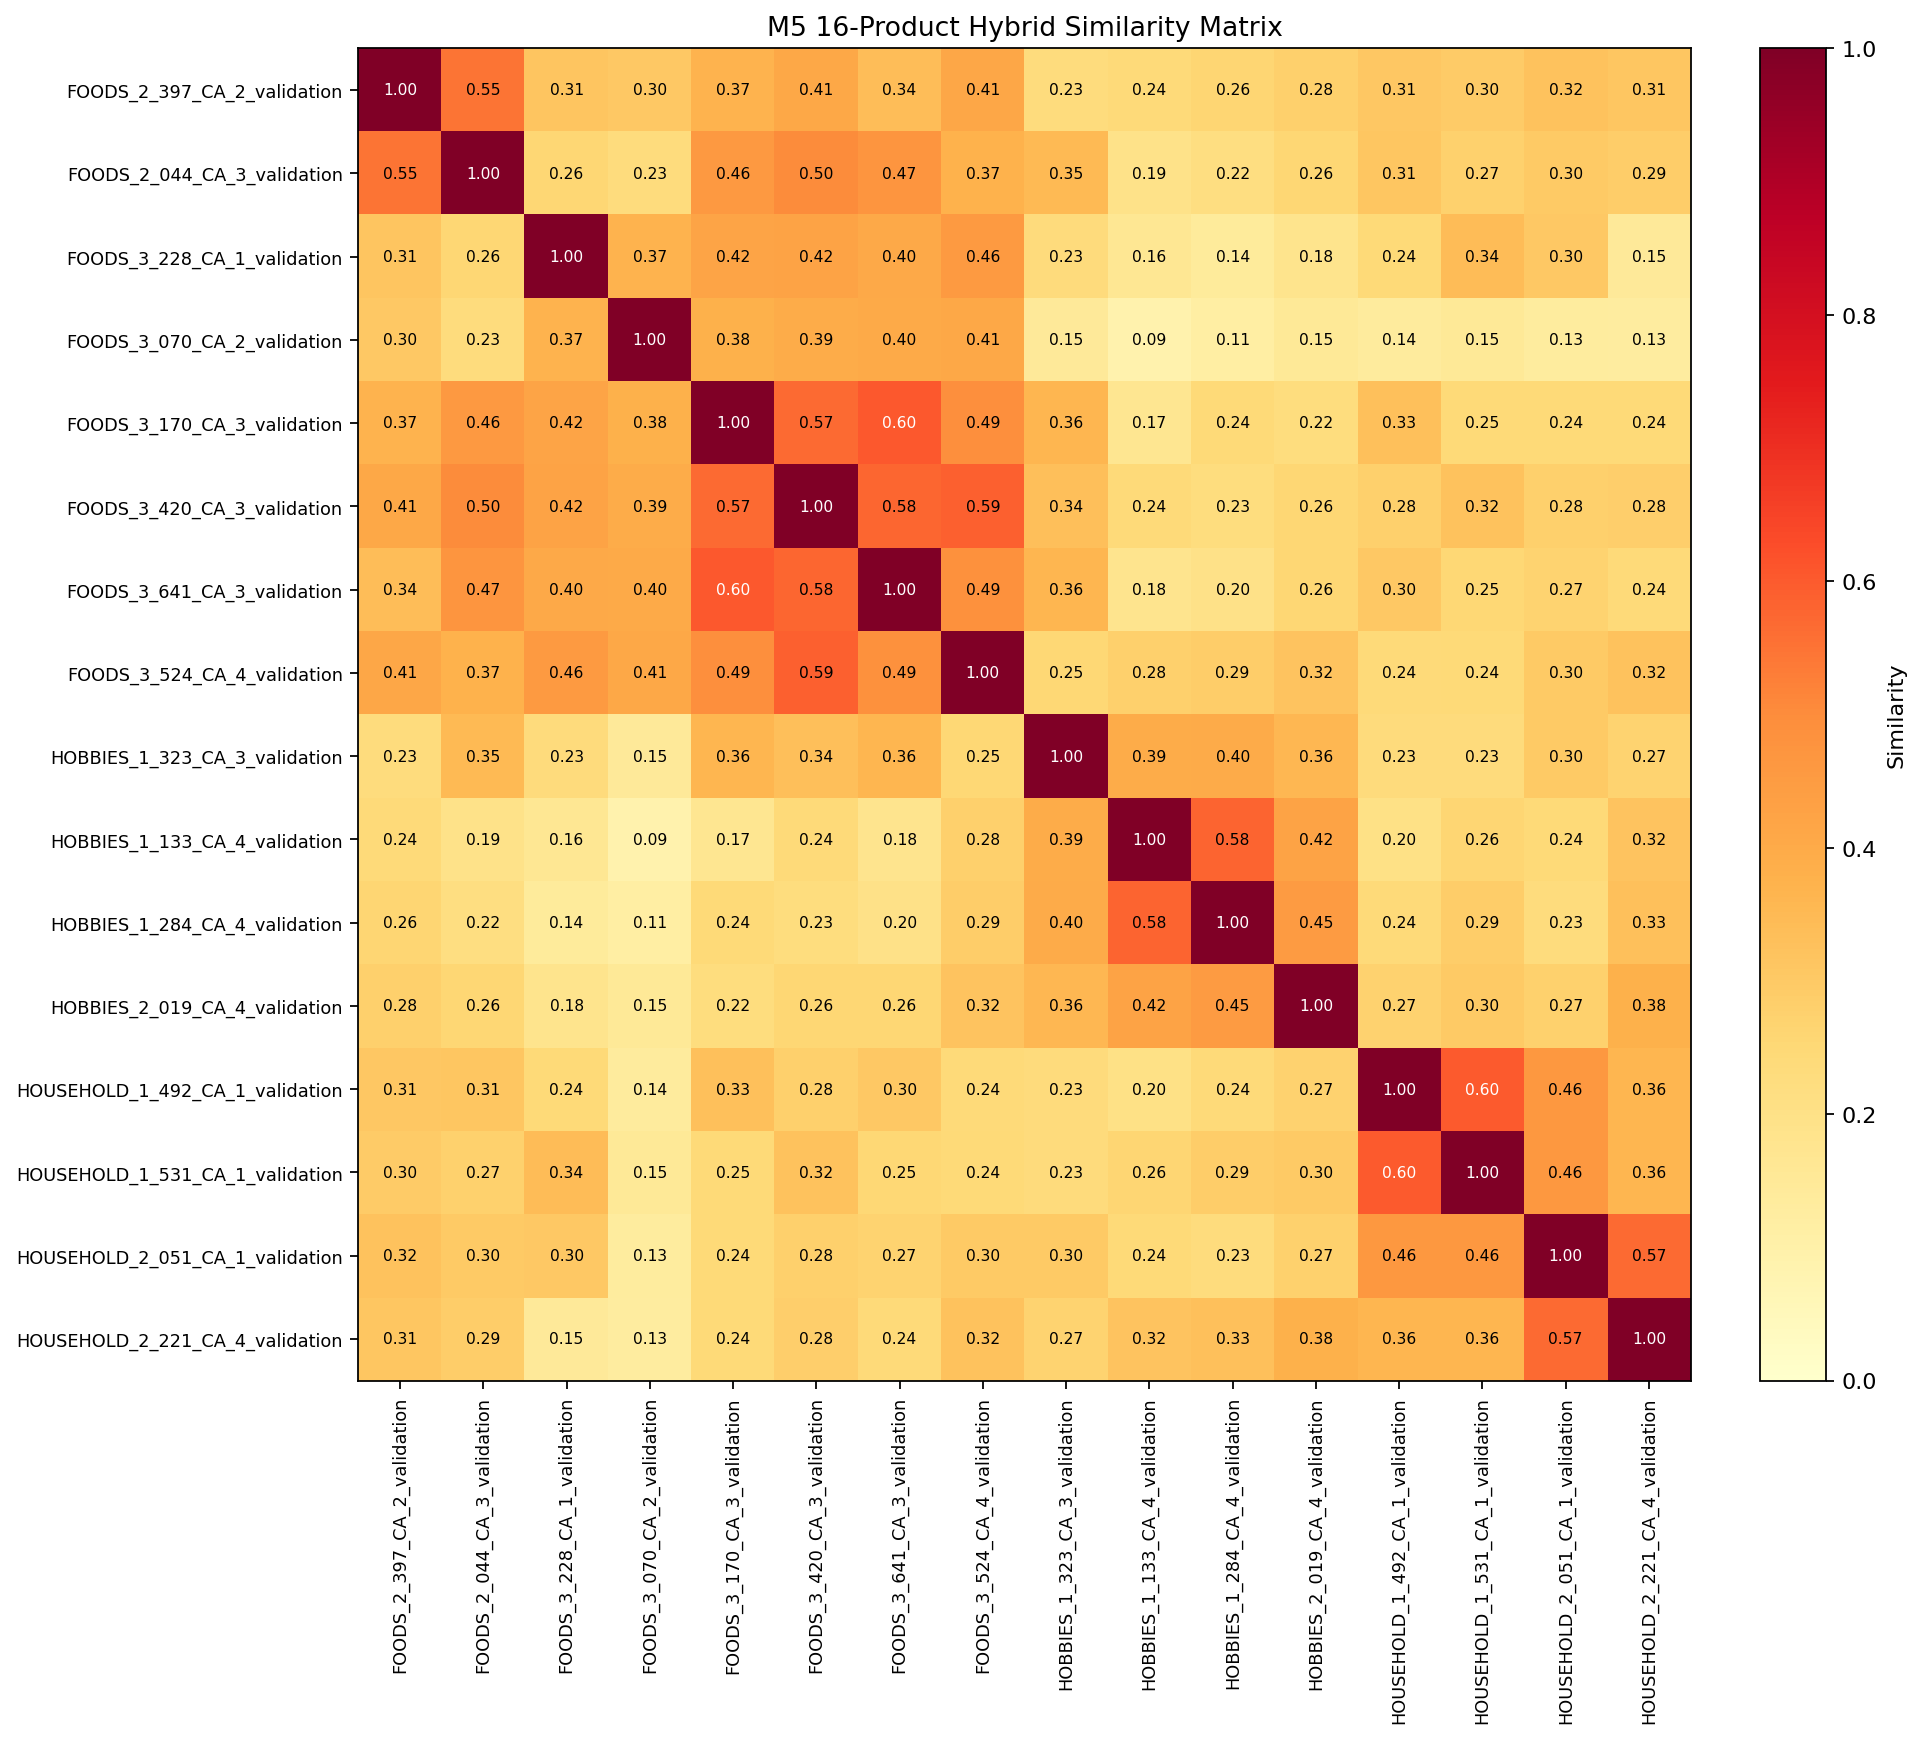

In [15]:
display(Image(filename=str(outputs['hybrid_heatmap_path'])))

In [16]:
hybrid_top_pairs_df.head(20)

,product_a,product_b,similarity,abs_similarity
0,FOODS_3_170_CA_3_validation,FOODS_3_641_CA_3_validation,0.6046,0.6046
1,HOUSEHOLD_1_492_CA_1_validation,HOUSEHOLD_1_531_CA_1_validation,0.6010,0.6010
2,FOODS_3_420_CA_3_validation,FOODS_3_524_CA_4_validation,0.5863,0.5863
3,HOBBIES_1_133_CA_4_validation,HOBBIES_1_284_CA_4_validation,0.5791,0.5791
4,FOODS_3_420_CA_3_validation,FOODS_3_641_CA_3_validation,0.5775,0.5775
5,HOUSEHOLD_2_051_CA_1_validation,HOUSEHOLD_2_221_CA_4_validation,0.5691,0.5691
6,FOODS_3_170_CA_3_validation,FOODS_3_420_CA_3_validation,0.5688,0.5688
7,FOODS_2_397_CA_2_validation,FOODS_2_044_CA_3_validation,0.5495,0.5495
8,FOODS_2_044_CA_3_validation,FOODS_3_420_CA_3_validation,0.5035,0.5035
9,FOODS_3_170_CA_3_validation,FOODS_3_524_CA_4_validation,0.4883,0.4883


In [17]:
hybrid_connectivity_df

,category,pair_type,mean_similarity
0,FOODS,cross_category,0.2469
1,FOODS,within_category,0.4268
2,HOBBIES,cross_category,0.2455
3,HOBBIES,within_category,0.4333
4,HOUSEHOLD,cross_category,0.2655
5,HOUSEHOLD,within_category,0.4698


In [18]:
hybrid_threshold_df

,threshold,edge_count,pair_coverage,connected_components,largest_component_size
0,0.5000,9,0.0750,8,6
1,0.8000,0,0.0000,16,1
2,0.9000,0,0.0000,16,1
3,0.9900,0,0.0000,16,1


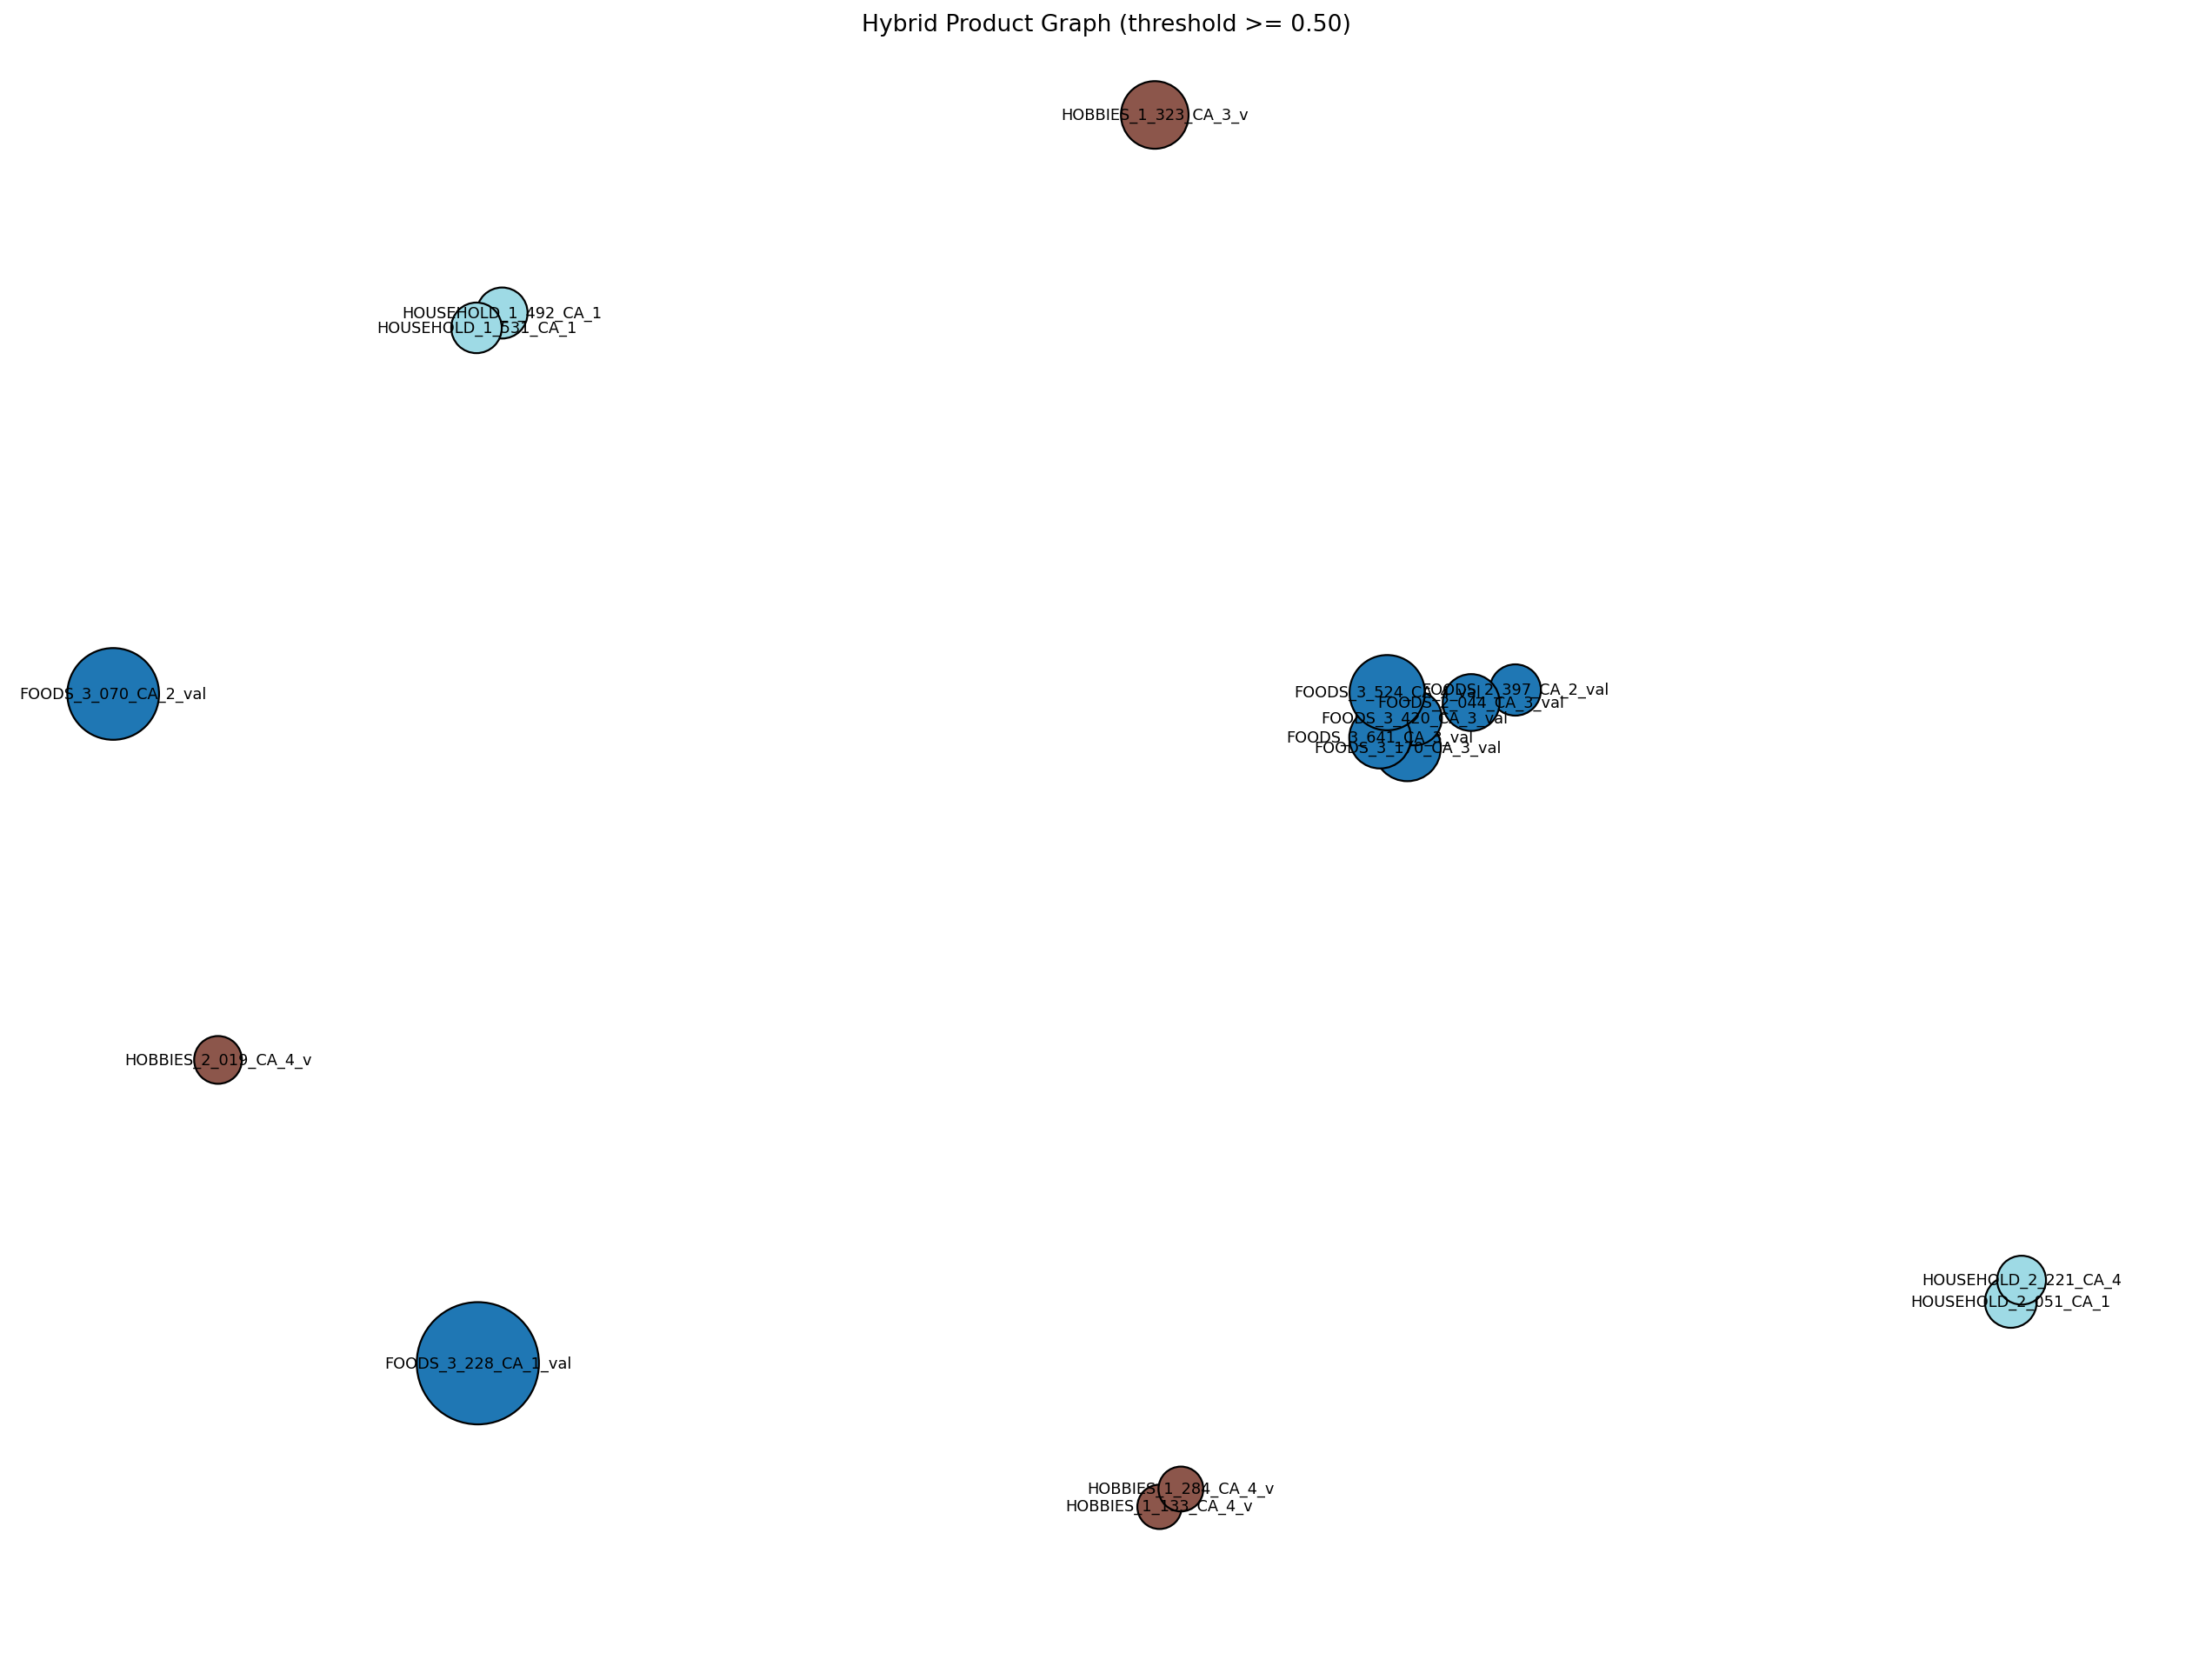

In [19]:
display(Image(filename=str(outputs['hybrid_graph_path'])))

## Raw Pearson vs Hybrid

The Pearson-only graph was weak because daily raw sales are sparse, noisy, and misaligned across products, which suppresses simple pairwise correlation.

The hybrid matrix is more aligned with Notebook 29 because it combines:

- stabilized sales similarity
- structural metadata relationships already used in the earlier graph prototype
- demand-profile similarity across smooth, intermittent, and low-volume products

This makes category-consistent clusters easier to recover and gives threshold graphs a better chance of remaining connected at moderate thresholds.

In [20]:
for line in outputs['hybrid_interpretation_lines']:
    print('-', line)

print('\nSaved hybrid files:')
print('-', outputs['profile_csv'])
print('-', outputs['daily_component_csv'])
print('-', outputs['weekly_component_csv'])
print('-', outputs['log_component_csv'])
print('-', outputs['sales_similarity_csv'])
print('-', outputs['metadata_similarity_csv'])
print('-', outputs['profile_similarity_csv'])
print('-', outputs['hybrid_csv'])
print('-', outputs['hybrid_top_pairs_csv'])
print('-', outputs['hybrid_connectivity_csv'])
print('-', outputs['hybrid_threshold_csv'])
print('-', outputs['hybrid_heatmap_path'])
print('-', outputs['hybrid_graph_path'])
print('-', outputs['hybrid_summary_path'])

- Hybrid similarity was defined as 0.40 * sales_similarity + 0.35 * metadata_similarity + 0.25 * profile_similarity.
- The sales block combines positive daily Pearson, weekly Pearson, and log1p Pearson to stabilize sparse daily series.
- The metadata block reuses the same category / department / store / state scoring idea from notebook29.
- The demand-profile block connects products with similar mean, spread, sparsity, and intermittency characteristics even when raw day-level correlation is weak.
- Top hybrid pairs: FOODS_3_170_CA_3_validation vs FOODS_3_641_CA_3_validation = 0.605; HOUSEHOLD_1_492_CA_1_validation vs HOUSEHOLD_1_531_CA_1_validation = 0.601; FOODS_3_420_CA_3_validation vs FOODS_3_524_CA_4_validation = 0.586; HOBBIES_1_133_CA_4_validation vs HOBBIES_1_284_CA_4_validation = 0.579; FOODS_3_420_CA_3_validation vs FOODS_3_641_CA_3_validation = 0.578
- Within-category hybrid connectivity ranks as HOUSEHOLD: 0.470, HOBBIES: 0.433, FOODS: 0.427.
- Hybrid threshold counts are 0.

## Visualization Fix: Clear Edges and Labels

The graph figures above keep the right graph structure, but some edges are still hard to see. This section keeps the exact same hybrid similarity matrix and threshold rule, and only improves the drawing style.

Layout strategy used here:

- detect connected components
- layout each component separately
- place components apart on a grid
- use darker, thicker edges and boxed edge labels for readability

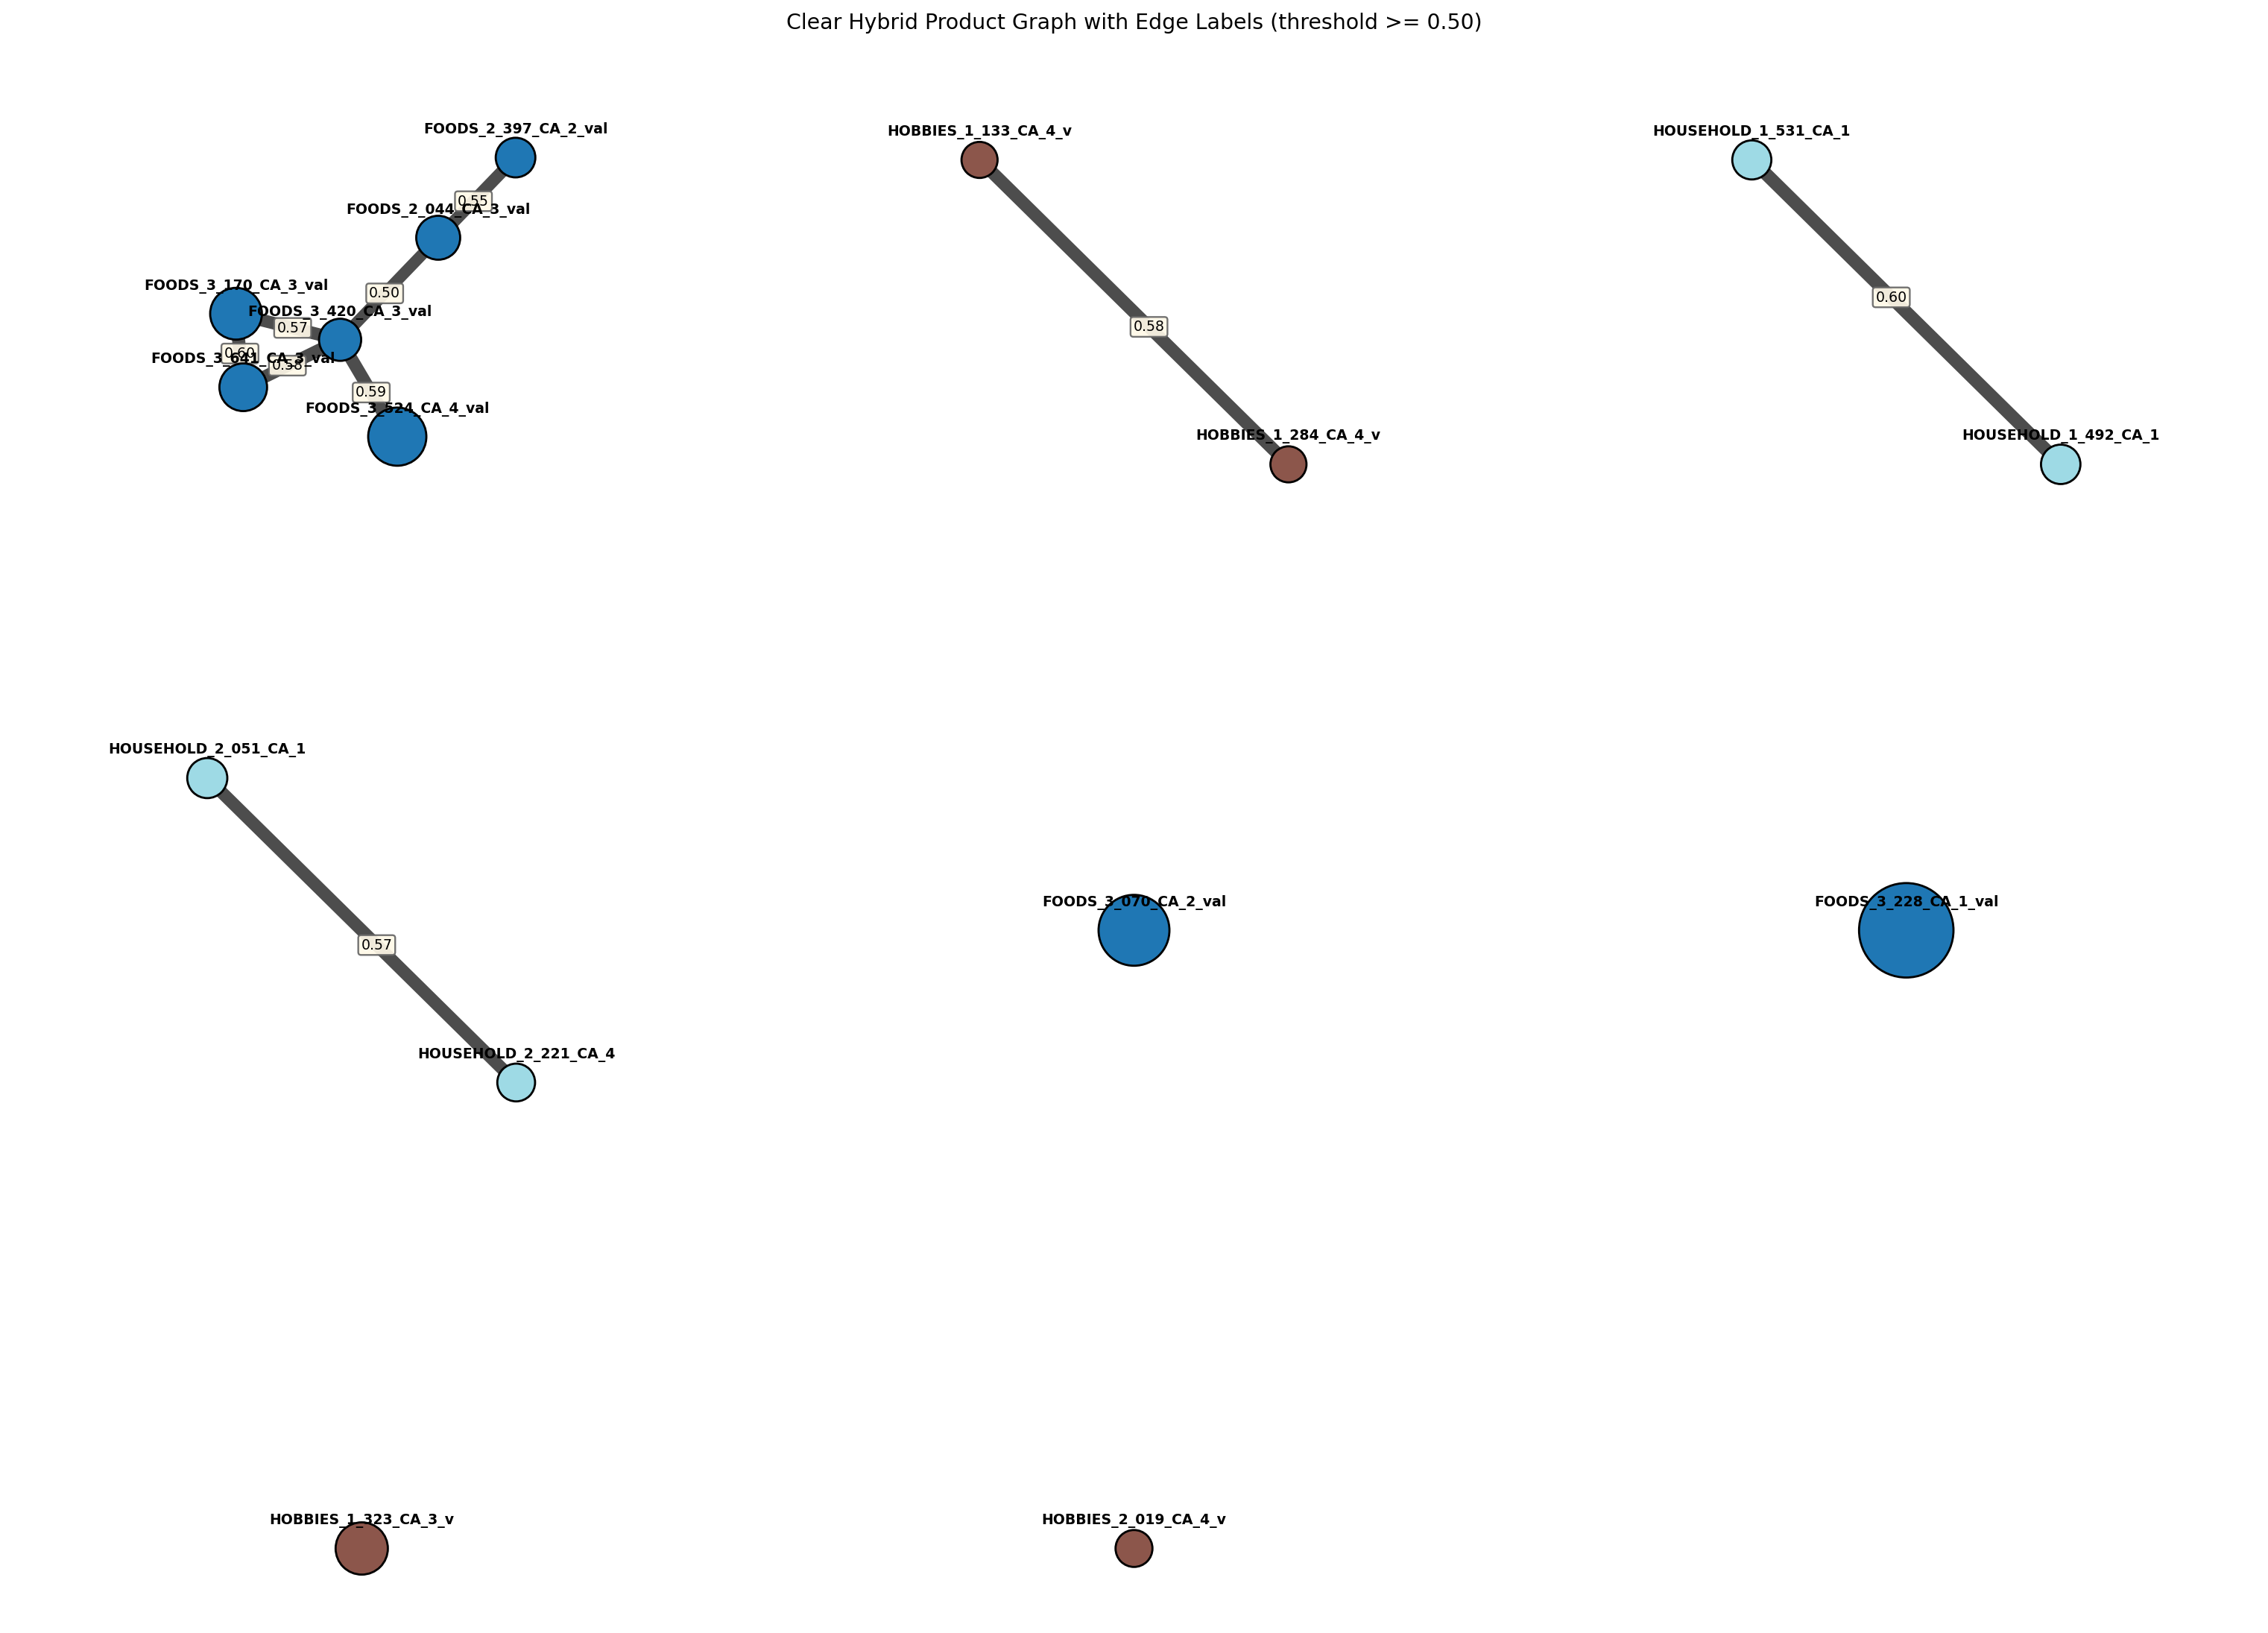

In [21]:
display(Image(filename=str(outputs['clear_threshold_graph_path'])))

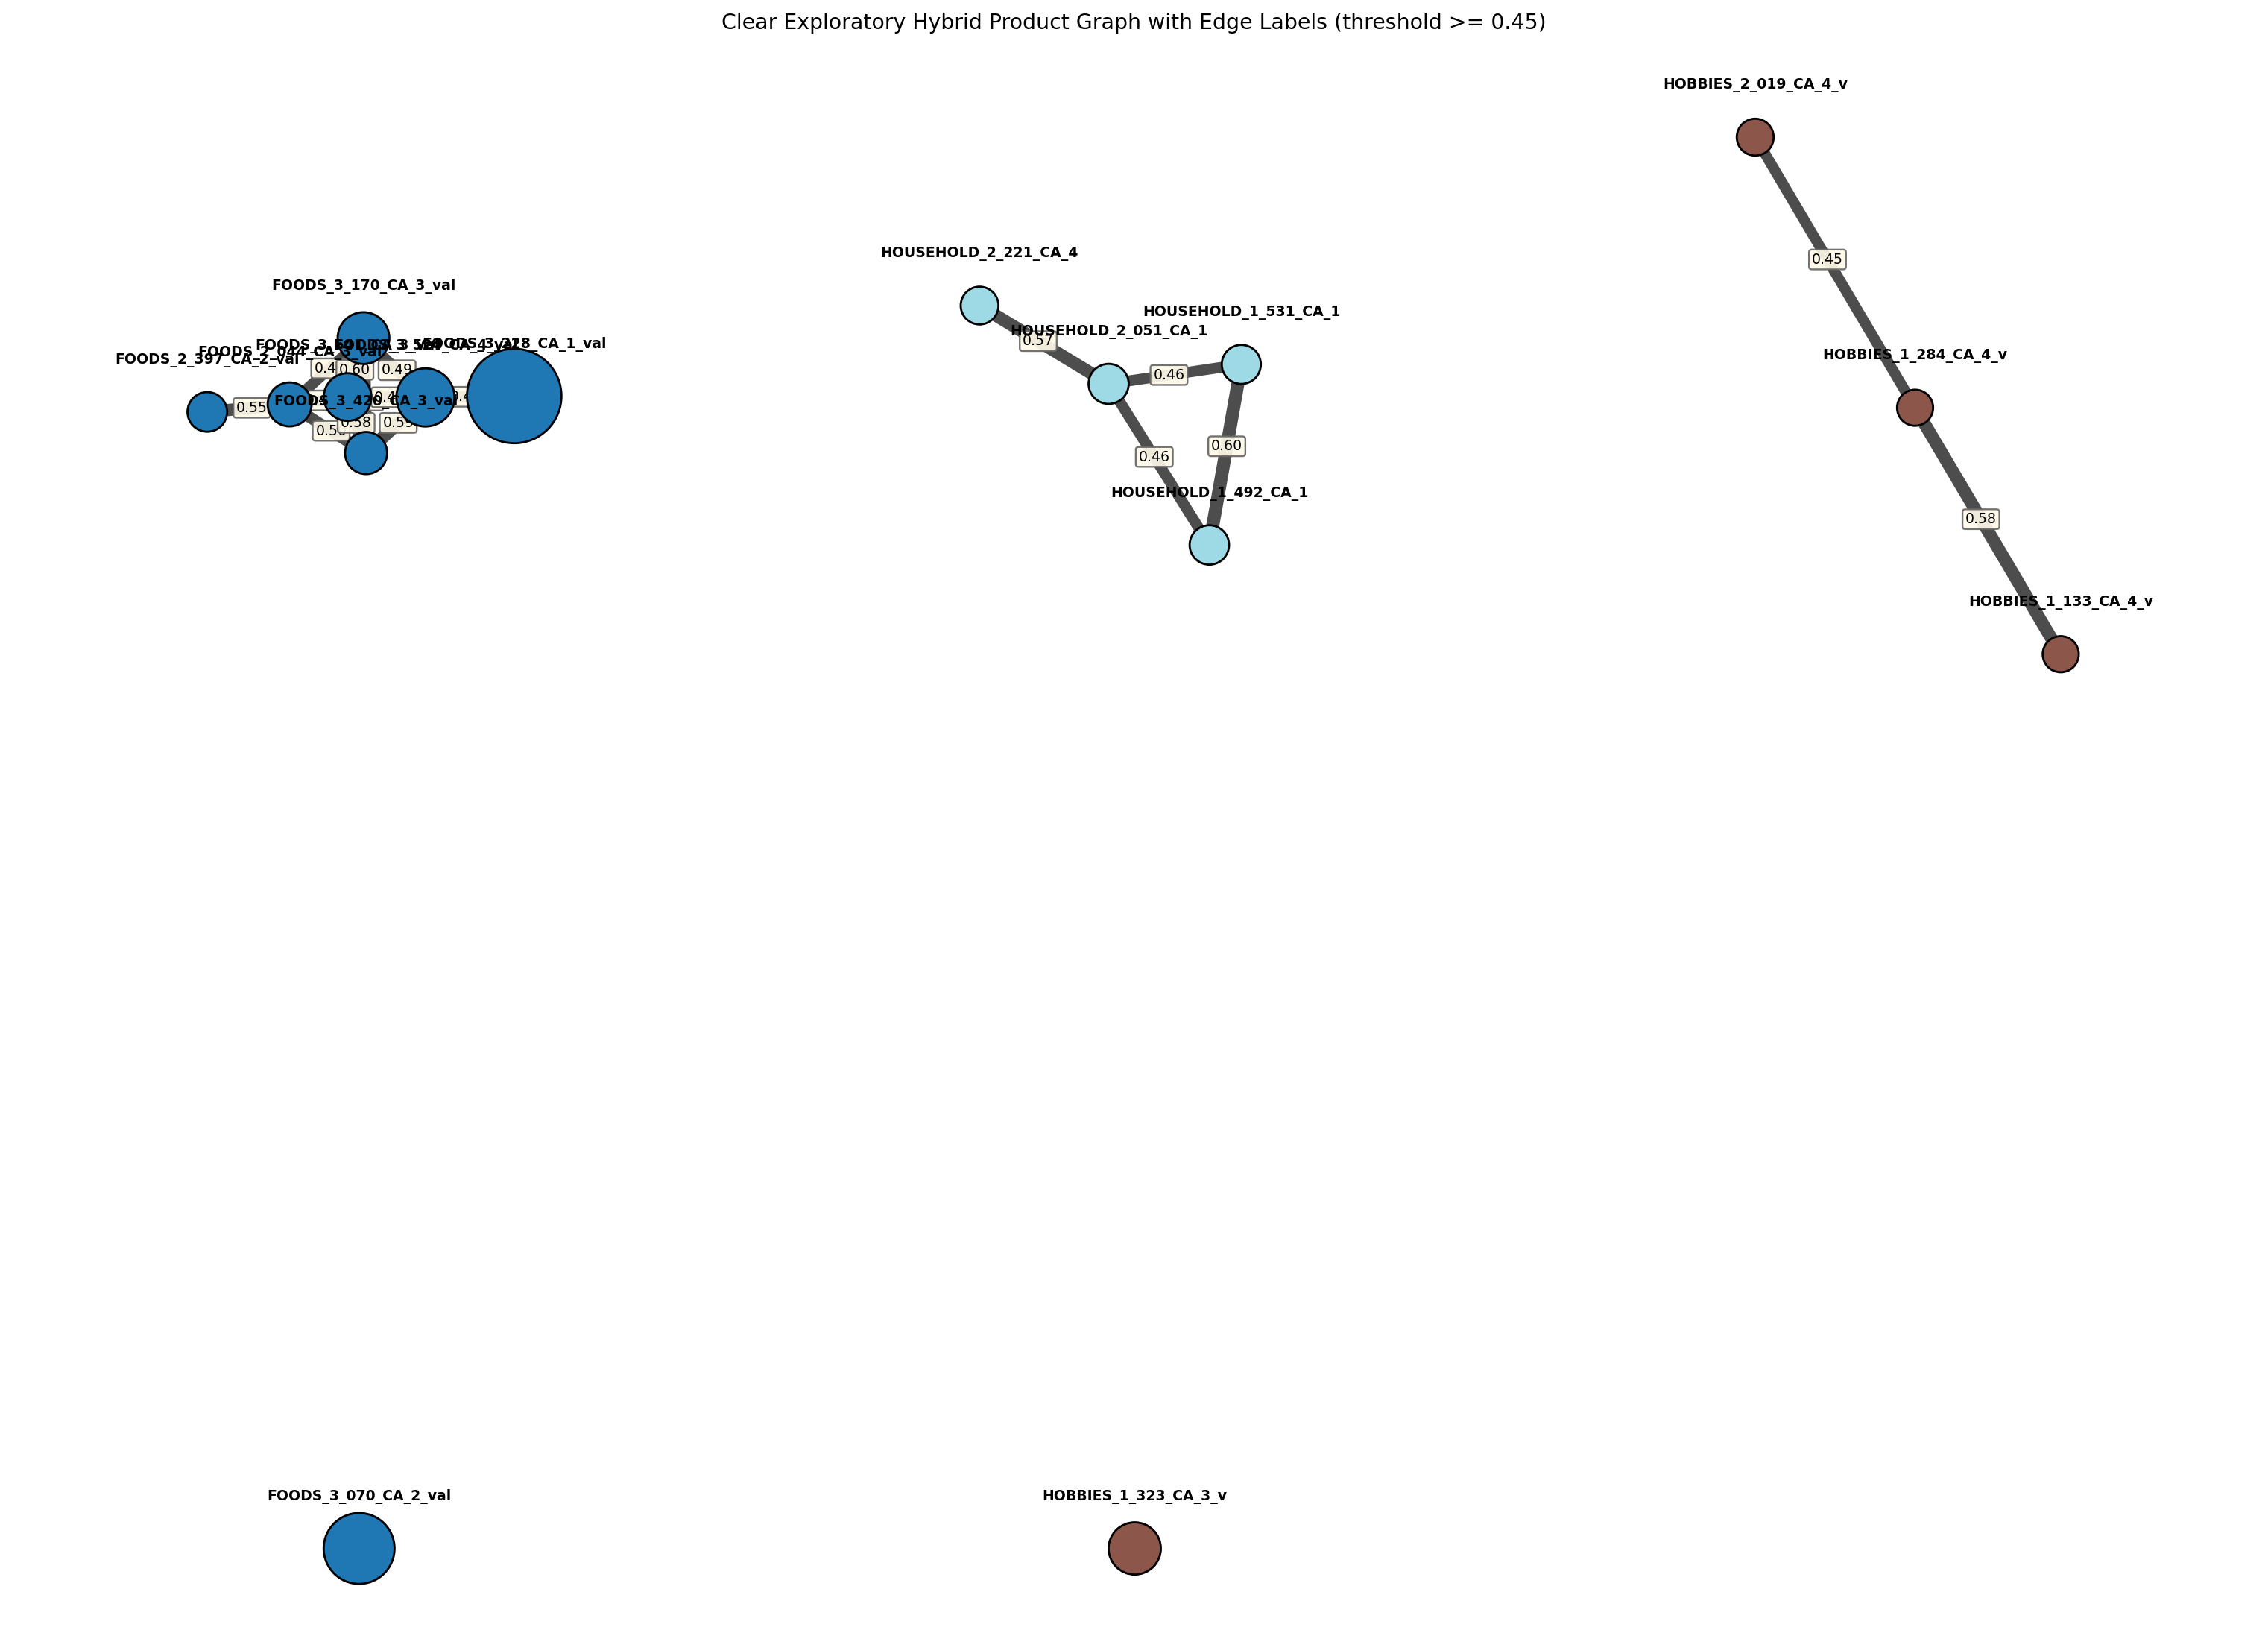

In [22]:
display(Image(filename=str(outputs['clear_exploratory_045_graph_path'])))

## Visualization Fix Note

The `0.50` graph here is still the formal result and keeps the same edge set as before. The `0.45` graph is exploratory only and helps reveal additional medium-strength structure without changing the underlying hybrid matrix.

In [23]:
for line in outputs['clear_visualization_lines']:
    print('-', line)

print('\nSaved visualization-fix files:')
print('-', outputs['clear_threshold_graph_path'])
print('-', outputs['clear_exploratory_045_graph_path'])
print('-', outputs['clear_viz_summary_path'])

- This visualization-fix section keeps the same threshold 0.50 graph result and only changes the drawing strategy.
- Connected components are laid out separately and then placed apart on a grid, which keeps edges from being hidden behind large nodes and reduces wasted space.
- Edges are darker and thicker, and edge labels are drawn in boxed annotations so weights such as 0.55 and 0.60 remain readable.
- The 0.45 figure is still exploratory only; it reveals additional medium-strength relationships while preserving the same hybrid similarity matrix.

Saved visualization-fix files:
- C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\correlation_matrix_16_products\hybrid_threshold_0_50_graph_component_layout.png
- C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\correlation_matrix_16_products\hybrid_threshold_0_45_graph_component_layout.png
- C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gn